In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from flowpde.datasets.exponax import PoissonGenerator, PoissonConfig
from flowpde.models.unet import UNet
from flowpde.datasets.normalization import FieldNormalizer
from flowpde.flows import NeuralODEFlow
from flowpde.objectives import FlowMatchingObjective
from flowpde.trainers.evaluation import FlowEvaluator
from flowpde.trainers import Trainer

In [2]:
cfg = PoissonConfig()
generator = PoissonGenerator(cfg)
train_data = generator.generate(num_samples = 1000, seed=0, problem='forward')
val_data   = generator.generate(num_samples = 50, seed=1, problem='forward')

Generated Poisson 2D dataset: 1000 samples, 64x64 grid
Generated Poisson 2D dataset: 50 samples, 64x64 grid


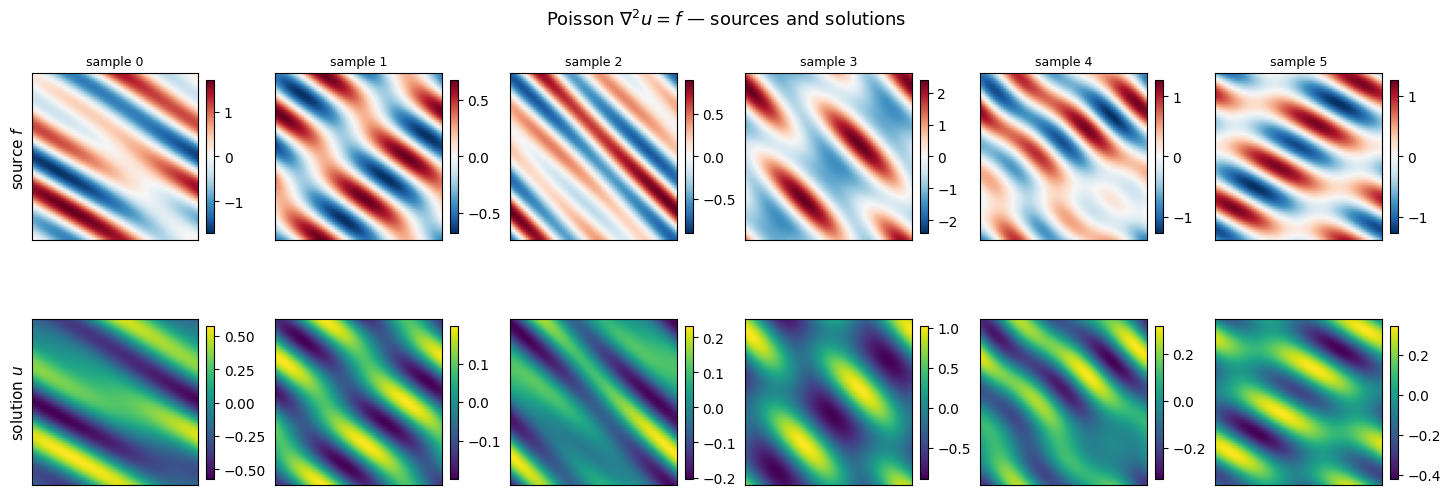

In [3]:
n=6
fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.2), constrained_layout=True)

for j in range(n):
    f = train_data.data['source'][j].squeeze().cpu().numpy()      # (H, W)
    u = train_data.data['solution'][j].squeeze().cpu().numpy()

    for row, (field, name, cmap) in enumerate(
        [(f, 'source $f$', 'RdBu_r'), (u, 'solution $u$', 'viridis')]
    ):
        ax = axes[row, j]
        vmax = abs(field).max()
        im = ax.imshow(
            field, cmap=cmap, origin='lower',
            **({'vmin': -vmax, 'vmax': vmax} if row == 0 else {}),
        )
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(name, fontsize=11)
        if row == 0:
            ax.set_title(f'sample {j}', fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046, shrink=0.9)

fig.suptitle(r'Poisson $\nabla^2 u = f$ — sources and solutions', fontsize=13)
plt.show()

In [4]:
normalizer = FieldNormalizer.from_dataset(train_data)
train_data.set_normalizer(normalizer)
val_data.set_normalizer(normalizer)

In [5]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
sample = train_data[0]
cond_ch = sample['input'].shape[0]      # +1 if obs masking is on
targ_ch = sample['target'].shape[0]
cond_ch, targ_ch

(1, 1)

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = UNet(spatial_dim = 2,
            spatial_size = 64,
            base_channels = 16,
            solution_channels = targ_ch,
            condition_channels = cond_ch,
            use_attention = False).to(device)

Using device: cuda


In [7]:
flow = NeuralODEFlow(model, 
                target_key = 'target', 
                condition_key = 'input')
flow = flow.to(device).float()

In [8]:
objective = FlowMatchingObjective(flow,
                                path = 'linear',
                                time_sampler = 'uniform')

In [ ]:
optimizer = torch.optim.Adam(objective.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In [ ]:
evaluator = FlowEvaluator(objective, 
                          val_loader,
                          target_key='target',
                          condition_key='input',
                          n_steps = 50,
                          solver='euler',
                          normalizer=normalizer,
                          target_fields=val_data.target_fields,
                          metrics=['rel_l2'],
                          max_batches=4,)

In [11]:
trainer = Trainer(objective,
                  optimizer,
                  scheduler,
                  device)

In [12]:
trainer.train(train_loader,
             epochs = 1000,
             print_stats_interval = 10,
             save_dir='../runs/poisson2d_fm',
             save_interval=25)

Epoch: 0001/1000 | Train_Loss: 1.941287 | LR: 1.00e-03 | Time: 0.845866
Epoch: 0011/1000 | Train_Loss: 0.29699 | LR: 9.93e-04 | Time: 0.434602
Epoch: 0021/1000 | Train_Loss: 0.17888 | LR: 9.73e-04 | Time: 0.429613
Epoch: 0031/1000 | Train_Loss: 0.13161 | LR: 9.42e-04 | Time: 0.427997
Epoch: 0041/1000 | Train_Loss: 0.092435 | LR: 9.00e-04 | Time: 0.433075
Epoch: 0051/1000 | Train_Loss: 0.066885 | LR: 8.48e-04 | Time: 0.429132
Epoch: 0061/1000 | Train_Loss: 0.069092 | LR: 7.88e-04 | Time: 0.429431
Epoch: 0071/1000 | Train_Loss: 0.063502 | LR: 7.20e-04 | Time: 0.428333
Epoch: 0081/1000 | Train_Loss: 0.052151 | LR: 6.47e-04 | Time: 0.42735
Epoch: 0091/1000 | Train_Loss: 0.070404 | LR: 5.70e-04 | Time: 0.429634
Epoch: 0101/1000 | Train_Loss: 0.049836 | LR: 4.92e-04 | Time: 0.429096
Epoch: 0111/1000 | Train_Loss: 0.03286 | LR: 4.14e-04 | Time: 0.434065
Epoch: 0121/1000 | Train_Loss: 0.032726 | LR: 3.38e-04 | Time: 0.43129
Epoch: 0131/1000 | Train_Loss: 0.030093 | LR: 2.66e-04 | Time: 0.42964

In [13]:
batch = next(iter(val_loader))

condition = batch["input"].to(device)   # normalized source f
target = batch["target"].to(device)     # normalized true solution u

with torch.no_grad():
    x_init = torch.randn_like(target)   # fixed starting noise for this draw

    pred = objective.sample(
        condition=condition,
        n_steps=100,
        solver="euler",
        x_init=x_init,
    )

    pred = pred.reshape_as(target)

In [14]:
pred_real = normalizer.denormalize_channels(
    val_data.target_fields,
    pred.cpu()
)

target_real = normalizer.denormalize_channels(
    val_data.target_fields,
    target.cpu()
)

source_real = normalizer.denormalize_channels(
    val_data.input_fields,
    condition.cpu()
)

In [15]:
rel_l2 = (
    torch.linalg.vector_norm((pred_real - target_real).flatten(1), dim=1)
    / torch.linalg.vector_norm(target_real.flatten(1), dim=1).clamp_min(1e-8)
)

print("Mean relative L2:", rel_l2.mean().item())

Mean relative L2: 0.06886553764343262


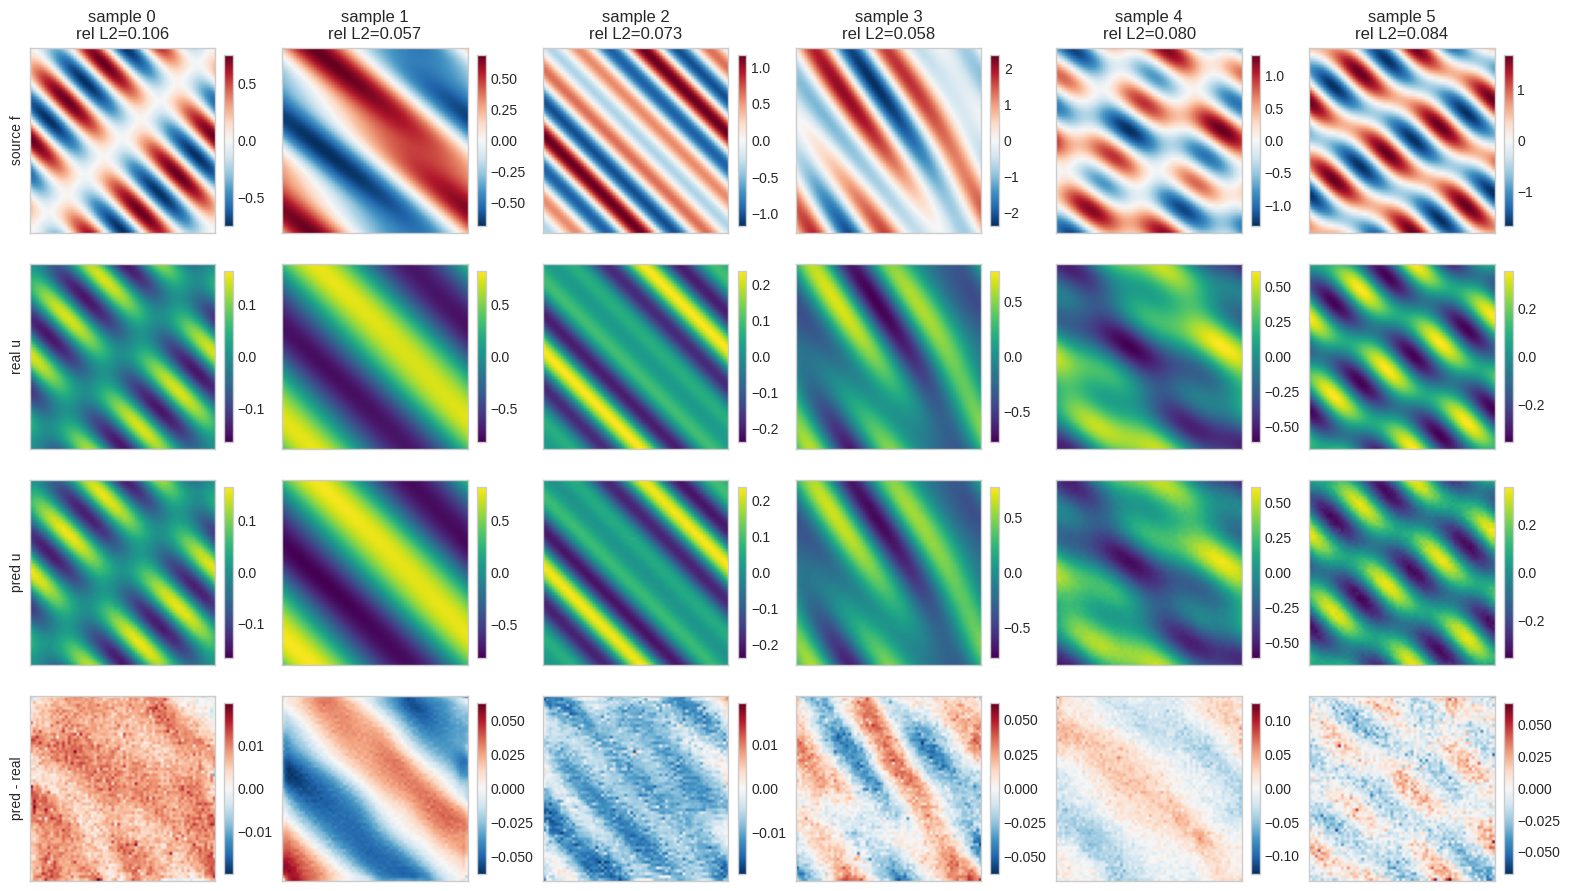

In [16]:
n = 6
fig, axes = plt.subplots(4, n, figsize=(2.6 * n, 9), constrained_layout=True)

for j in range(n):
    f = source_real[j, 0].numpy()
    u_true = target_real[j, 0].numpy()
    u_pred = pred_real[j, 0].numpy()
    err = u_pred - u_true

    vmax_f = abs(f).max()
    vmax_u = max(abs(u_true).max(), abs(u_pred).max())
    vmax_e = abs(err).max()

    rows = [
        (f, "source f", "RdBu_r", -vmax_f, vmax_f),
        (u_true, "real u", "viridis", -vmax_u, vmax_u),
        (u_pred, "pred u", "viridis", -vmax_u, vmax_u),
        (err, "pred - real", "RdBu_r", -vmax_e, vmax_e),
    ]

    for i, (field, label, cmap, vmin, vmax) in enumerate(rows):
        ax = axes[i, j]
        im = ax.imshow(field, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks([])
        ax.set_yticks([])

        if j == 0:
            ax.set_ylabel(label)

        if i == 0:
            ax.set_title(f"sample {j}\nrel L2={rel_l2[j]:.3f}")

        fig.colorbar(im, ax=ax, fraction=0.046, shrink=0.85)

plt.show()